# IA Responsable, German Credit Dataset

**IA708, Télécom Paris, 2026**

Ce notebook s'appuie sur les bibliothèques standard du domaine : `scikit-learn`, `fairlearn`, `shap`. Le code reste compact et lisible.

On étudie un modèle de scoring crédit sous trois angles :
* **Équité** : le modèle traite-t-il les groupes de manière juste ?
* **Interprétabilité** : quelles variables influencent les décisions ?
* **Quantification d'incertitude** : intervalles de confiance par bootstrap (cf. cours *Robustness and Uncertainty*).

## 1. Chargement des données et traduction des labels

Le fichier `german.data` ([Hofmann 1994](#ref-hofmann1994)) encode plusieurs variables catégorielles avec des codes de la forme `Axx` (`A11`, `A34`, etc.). On applique une traduction systématique en libellés clairs (français), d'après `german.pdf`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)
os.makedirs("outputs", exist_ok=True)

COLUMNS = [
    "checking_status", "duration_in_month", "credit_history", "purpose",
    "credit_amount", "savings_account_bonds", "present_employment_since",
    "installment_rate", "personal_status_sex", "other_debtors_guarantors",
    "present_residence_since", "property", "age_in_years",
    "other_installment_plans", "housing", "number_of_existing_credits",
    "job", "number_of_people_liable", "telephone", "foreign_worker",
    "raw_target",
]

LABEL_MAP_BY_CATEGORY = {
    "checking_status": {
        "A11": "< 0 DM",
        "A12": "0 <= solde < 200 DM",
        "A13": "solde >= 200 DM (ou salaire domicilié >= 1 an)",
        "A14": "pas de compte courant",
    },
    "credit_history": {
        "A30": "aucun crédit ou tous remboursés à temps",
        "A31": "tous les crédits dans cette banque remboursés",
        "A32": "crédits existants remboursés correctement jusqu'ici",
        "A33": "retards de paiement dans le passé",
        "A34": "compte critique / autres crédits existants",
    },
    "purpose": {
        "A40": "voiture (neuve)",
        "A41": "voiture (occasion)",
        "A42": "meubles / équipement",
        "A43": "radio / télévision",
        "A44": "électroménager",
        "A45": "réparations",
        "A46": "éducation",
        "A47": "vacances (valeur indiquée comme non utilisée)",
        "A48": "reconversion",
        "A49": "business",
        "A410": "autres",
    },
    "savings_account_bonds": {
        "A61": "< 100 DM",
        "A62": "100 <= épargne < 500 DM",
        "A63": "500 <= épargne < 1000 DM",
        "A64": "épargne >= 1000 DM",
        "A65": "inconnu / pas de compte épargne",
    },
    "present_employment_since": {
        "A71": "sans emploi",
        "A72": "< 1 an",
        "A73": "1 <= ancienneté < 4 ans",
        "A74": "4 <= ancienneté < 7 ans",
        "A75": "ancienneté >= 7 ans",
    },
    "personal_status_sex": {
        "A91": "homme, divorcé/séparé",
        "A92": "femme, divorcée/séparée/mariée",
        "A93": "homme, célibataire",
        "A94": "homme, marié/veuf",
        "A95": "femme, célibataire",
    },
    "other_debtors_guarantors": {
        "A101": "aucun",
        "A102": "co-demandeur",
        "A103": "garant",
    },
    "property": {
        "A121": "immobilier",
        "A122": "épargne logement / assurance-vie",
        "A123": "voiture ou autre (hors attr. 6)",
        "A124": "inconnu / pas de propriété",
    },
    "other_installment_plans": {
        "A141": "banque",
        "A142": "magasins",
        "A143": "aucun",
    },
    "housing": {
        "A151": "locataire",
        "A152": "propriétaire",
        "A153": "hébergé gratuitement",
    },
    "job": {
        "A171": "sans emploi / non qualifié non-résident",
        "A172": "non qualifié résident",
        "A173": "employé qualifié / officiel",
        "A174": "management / indépendant / hautement qualifié",
    },
    "telephone": {
        "A191": "aucun téléphone",
        "A192": "oui, au nom du client",
    },
    "foreign_worker": {
        "A201": "oui",
        "A202": "non",
    },
}

raw = pd.read_csv("data/raw/german.data", sep=r"\s+", header=None, names=COLUMNS)
for col, mapping in LABEL_MAP_BY_CATEGORY.items():
    raw[col] = raw[col].astype(str).map(mapping).fillna(raw[col].astype(str))
raw["default"] = (raw["raw_target"] == 2).astype(int)

print(f"Dataset : {raw.shape[0]} lignes, {raw.shape[1]} colonnes")
print(f"Taux de défaut : {raw['default'].mean():.1%}")
raw.head(3)

Dataset : 1000 lignes, 22 colonnes
Taux de défaut : 30.0%


,checking_status,duration_in_month,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate,personal_status_sex,other_debtors_guarantors,...,age_in_years,other_installment_plans,housing,number_of_existing_credits,job,number_of_people_liable,telephone,foreign_worker,raw_target,default
0,< 0 DM,6,compte critique / autres crédits existants,radio / télévision,1169,inconnu / pas de compte épargne,ancienneté >= 7 ans,4,"homme, célibataire",aucun,...,67,aucun,propriétaire,2,employé qualifié / officiel,1,"oui, au nom du client",oui,1,0
1,0 <= solde < 200 DM,48,crédits existants remboursés correctement jusq...,radio / télévision,5951,< 100 DM,1 <= ancienneté < 4 ans,2,"femme, divorcée/séparée/mariée",aucun,...,22,aucun,propriétaire,1,employé qualifié / officiel,1,aucun téléphone,oui,2,1
2,pas de compte courant,12,compte critique / autres crédits existants,éducation,2096,< 100 DM,4 <= ancienneté < 7 ans,2,"homme, célibataire",aucun,...,49,aucun,propriétaire,1,non qualifié résident,2,aucun téléphone,oui,1,0


### 1.1 Table de conversion des codes

Pour traçabilité, on affiche la table complète : code source vs signification exacte (`german.pdf`) vs label clair appliqué.

In [2]:
EXACT_MEANINGS_PDF = {
    "checking_status": {
        "A11": "... < 0 DM",
        "A12": "0 <= ... < 200 DM",
        "A13": "... >= 200 DM / salary assignments for at least 1 year",
        "A14": "no checking account",
    },
    "credit_history": {
        "A30": "no credits taken / all credits paid back duly",
        "A31": "all credits at this bank paid back duly",
        "A32": "existing credits paid back duly till now",
        "A33": "delay in paying off in the past",
        "A34": "critical account / other credits existing (not at this bank)",
    },
    "purpose": {
        "A40": "car (new)", "A41": "car (used)", "A42": "furniture/equipment",
        "A43": "radio/television", "A44": "domestic appliances", "A45": "repairs",
        "A46": "education", "A47": "(vacation - does not exist?)", "A48": "retraining",
        "A49": "business", "A410": "others",
    },
    "savings_account_bonds": {
        "A61": "... < 100 DM", "A62": "100 <= ... < 500 DM", "A63": "500 <= ... < 1000 DM",
        "A64": "... >= 1000 DM", "A65": "unknown / no savings account",
    },
    "present_employment_since": {
        "A71": "unemployed", "A72": "... < 1 year", "A73": "1 <= ... < 4 years",
        "A74": "4 <= ... < 7 years", "A75": "... >= 7 years",
    },
    "personal_status_sex": {
        "A91": "male : divorced/separated", "A92": "female : divorced/separated/married",
        "A93": "male : single", "A94": "male : married/widowed", "A95": "female : single",
    },
    "other_debtors_guarantors": {
        "A101": "none", "A102": "co-applicant", "A103": "guarantor",
    },
    "property": {
        "A121": "real estate",
        "A122": "if not A121: building society savings agreement/life insurance",
        "A123": "if not A121/A122: car or other, not in attribute 6",
        "A124": "unknown / no property",
    },
    "other_installment_plans": {"A141": "bank", "A142": "stores", "A143": "none"},
    "housing": {"A151": "rent", "A152": "own", "A153": "for free"},
    "job": {
        "A171": "unemployed / unskilled - non-resident",
        "A172": "unskilled - resident",
        "A173": "skilled employee / official",
        "A174": "management / self-employed / highly qualified employee / officer",
    },
    "telephone": {"A191": "none", "A192": "yes, registered under the customer's name"},
    "foreign_worker": {"A201": "yes", "A202": "no"},
}

rows = []
for category, exact_map in EXACT_MEANINGS_PDF.items():
    clear_map = LABEL_MAP_BY_CATEGORY.get(category, {})
    for code, exact_txt in exact_map.items():
        rows.append({
            "Catégorie": category,
            "Code": code,
            "Signification exacte (german.pdf)": exact_txt,
            "Label clair (FR)": clear_map.get(code, ""),
        })
conversion_table = pd.DataFrame(rows).sort_values(["Catégorie", "Code"]).reset_index(drop=True)
print("Table globale: code -> signification exacte -> label clair")
display(conversion_table)

Table globale: code -> signification exacte -> label clair


,Catégorie,Code,Signification exacte (german.pdf),Label clair (FR)
0,checking_status,A11,... < 0 DM,< 0 DM
1,checking_status,A12,0 <= ... < 200 DM,0 <= solde < 200 DM
2,checking_status,A13,... >= 200 DM / salary assignments for at leas...,solde >= 200 DM (ou salaire domicilié >= 1 an)
3,checking_status,A14,no checking account,pas de compte courant
4,credit_history,A30,no credits taken / all credits paid back duly,aucun crédit ou tous remboursés à temps
5,credit_history,A31,all credits at this bank paid back duly,tous les crédits dans cette banque remboursés
6,credit_history,A32,existing credits paid back duly till now,crédits existants remboursés correctement jusq...
7,credit_history,A33,delay in paying off in the past,retards de paiement dans le passé
8,credit_history,A34,critical account / other credits existing (not...,compte critique / autres crédits existants
9,foreign_worker,A201,yes,oui


## 2. Exploration

Le dataset est **déséquilibré** (70% bon payeur, 30% mauvais).
On extrait deux **attributs sensibles** :
* **Genre** depuis `personal_status_sex` (qui est maintenant en libellé clair)
* **Âge** binarisé au seuil de 25 ans (jeunes vs plus âgés), convention standard issue de [Kamiran & Calders 2012](#ref-kamiran2012), reprise par [AIF360, Bellamy et al. 2018](#ref-bellamy2018) et [Friedler et al. 2019](#ref-friedler2019)

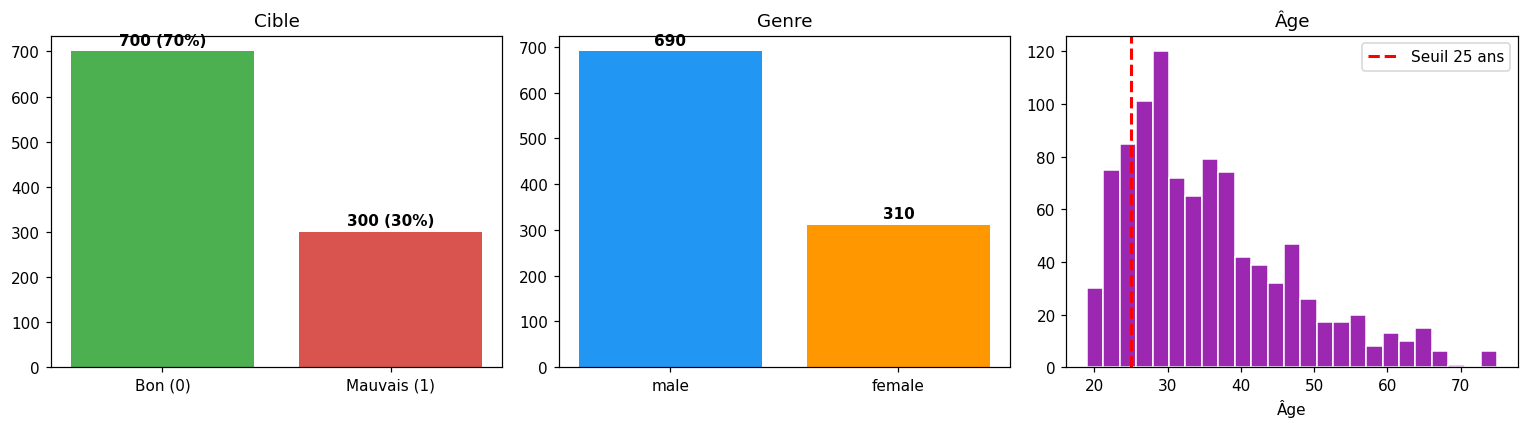

In [3]:
GENDER_MAP = {
    "homme, divorcé/séparé": "male",
    "homme, célibataire": "male",
    "homme, marié/veuf": "male",
    "femme, divorcée/séparée/mariée": "female",
    "femme, célibataire": "female",
}
raw["gender"] = raw["personal_status_sex"].map(GENDER_MAP).fillna("unknown")
raw["age_group"] = np.where(raw["age_in_years"] > 25, "older", "younger")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

c = raw["default"].value_counts().sort_index()
axes[0].bar(["Bon (0)", "Mauvais (1)"], c.values, color=["#4CAF50", "#d9534f"])
axes[0].set_title("Cible")
for i, v in enumerate(c.values):
    axes[0].text(i, v + 15, f"{v} ({v/len(raw):.0%})", ha="center", fontweight="bold")

g = raw["gender"].value_counts()
axes[1].bar(g.index, g.values, color=["#2196F3", "#FF9800"])
axes[1].set_title("Genre")
for i, v in enumerate(g.values):
    axes[1].text(i, v + 15, f"{v}", ha="center", fontweight="bold")

axes[2].hist(raw["age_in_years"], bins=25, color="#9C27B0", edgecolor="white")
axes[2].axvline(25, color="red", ls="--", lw=2, label="Seuil 25 ans")
axes[2].set_title("Âge")
axes[2].legend()
axes[2].set_xlabel("Âge")

plt.tight_layout()
plt.savefig("outputs/01_exploration.png", bbox_inches="tight")
plt.show()

In [4]:
for name, col in [("Genre", "gender"), ("Âge", "age_group")]:
    ct = pd.crosstab(raw[col], raw["default"], normalize="index").round(3)
    ct.columns = ["P(bon)", "P(défaut)"]
    print(f"Taux de défaut par {name}")
    print(ct.to_string(), "\n")


Taux de défaut par Genre
        P(bon)  P(défaut)
gender                   
female   0.648      0.352
male     0.723      0.277 

Taux de défaut par Âge
           P(bon)  P(défaut)
age_group                   
older       0.728      0.272
younger     0.579      0.421 



## 3. Préparation

**Choix clé** : on **retire** `personal_status_sex` et `age_in_years` des features pour éviter la discrimination directe. Mais des **proxies** peuvent persister, on vérifiera via SHAP et corrélations.

Pipeline `sklearn` ([Pedregosa et al. 2011](#ref-pedregosa2011)) :
* `StandardScaler` pour les variables numériques
* `OneHotEncoder` pour les variables catégorielles

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

sensitive = {
    "gender": raw["gender"].values,
    "age": raw["age_group"].values,
}
PRIVILEGED = {"gender": "male", "age": "older"}

features = raw.drop(columns=[
    "raw_target", "default", "personal_status_sex", "age_in_years",
    "gender", "age_group",
])
y = raw["default"].values

NUMERIC = ["duration_in_month", "credit_amount", "installment_rate",
           "present_residence_since", "number_of_existing_credits",
           "number_of_people_liable"]
CATEG = [c for c in features.columns if c not in NUMERIC]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEG),
])

idx = np.arange(len(y))
idx_trval, idx_te = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
y_trval = y[idx_trval]
idx_tr, idx_va = train_test_split(idx_trval, test_size=0.25, stratify=y_trval, random_state=42)

X_tr = preprocessor.fit_transform(features.iloc[idx_tr])
X_va = preprocessor.transform(features.iloc[idx_va])
X_te = preprocessor.transform(features.iloc[idx_te])
y_tr, y_va, y_te = y[idx_tr], y[idx_va], y[idx_te]

feature_names = preprocessor.get_feature_names_out()
feature_names = [n.split("__", 1)[-1] for n in feature_names]

print(f"Train: {len(idx_tr)}, Val: {len(idx_va)}, Test: {len(idx_te)}")
print(f"Features après encoding : {X_tr.shape[1]} colonnes ({len(NUMERIC)} num, {len(CATEG)} cat)")

Train: 600, Val: 200, Test: 200
Features après encoding : 56 colonnes (6 num, 12 cat)


## 4. Modèle baseline : régression logistique

On utilise `sklearn.linear_model.LogisticRegression` ([Pedregosa et al. 2011](#ref-pedregosa2011)). Le modèle :

$$P(\text{défaut}=1 \mid x) = \sigma(w^\top x + b)$$

avec régularisation L2 et solveur `liblinear`.

Convergence (vérification équipe : seuil ~100 itérations, loss attendue ~0.5)
 n_iter  loss_train  loss_val  AUC_val
     10      0.4318    0.5574   0.7276
     25      0.4318    0.5574   0.7276
     50      0.4318    0.5574   0.7276
     75      0.4318    0.5574   0.7276
    100      0.4318    0.5574   0.7276
    150      0.4318    0.5574   0.7276
    200      0.4318    0.5574   0.7276
    500      0.4318    0.5574   0.7276
   1000      0.4318    0.5574   0.7276


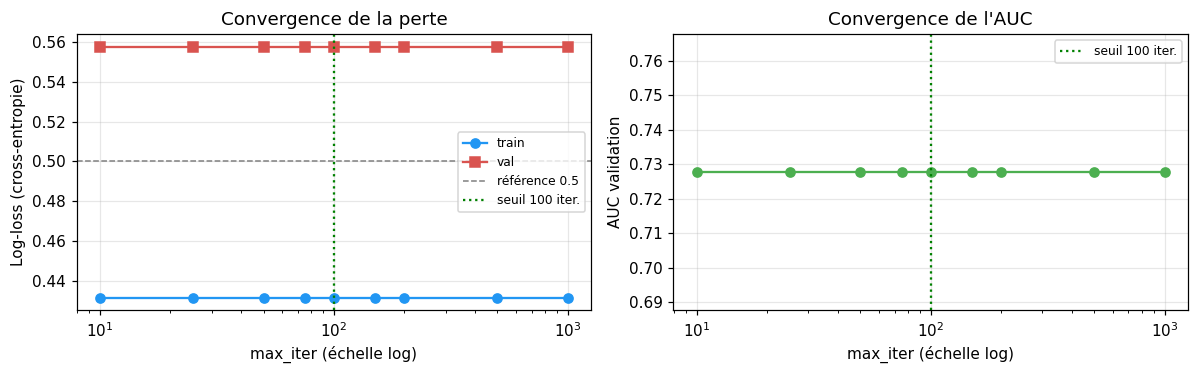


Log-loss train final : 0.4318
Seuil optimal (sur validation) : 0.180
AUC test : 0.7851
Balanced accuracy test : 0.6690


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, log_loss

def best_threshold(y_true, scores):
    """Seuil qui maximise la balanced accuracy sur la validation."""
    candidates = np.linspace(0.1, 0.9, 81)
    bas = [balanced_accuracy_score(y_true, (scores >= t).astype(int)) for t in candidates]
    return candidates[int(np.argmax(bas))]

# Vérification de convergence (feedback équipe : convergence attendue à partir de 100 itérations,
# log-loss attendue ~0.5 sur ce dataset déséquilibré 70/30)
convergence_history = []
for n_iter in [10, 25, 50, 75, 100, 150, 200, 500, 1000]:
    m = LogisticRegression(C=1.0, solver="liblinear", max_iter=n_iter, random_state=42)
    m.fit(X_tr, y_tr)
    p_va = m.predict_proba(X_va)[:, 1]
    convergence_history.append({
        "n_iter": n_iter,
        "loss_train": log_loss(y_tr, m.predict_proba(X_tr)[:, 1]),
        "loss_val": log_loss(y_va, p_va),
        "AUC_val": roc_auc_score(y_va, p_va),
    })
conv_df = pd.DataFrame(convergence_history)
print("Convergence (vérification équipe : seuil ~100 itérations, loss attendue ~0.5)")
print(conv_df.to_string(index=False, float_format="{:.4f}".format))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(conv_df["n_iter"], conv_df["loss_train"], "o-", label="train", color="#2196F3")
axes[0].plot(conv_df["n_iter"], conv_df["loss_val"], "s-", label="val", color="#d9534f")
axes[0].axhline(0.5, color="grey", ls="--", lw=1, label="référence 0.5")
axes[0].axvline(100, color="green", ls=":", lw=1.5, label="seuil 100 iter.")
axes[0].set_xscale("log")
axes[0].set_xlabel("max_iter (échelle log)")
axes[0].set_ylabel("Log-loss (cross-entropie)")
axes[0].set_title("Convergence de la perte")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(conv_df["n_iter"], conv_df["AUC_val"], "o-", color="#4CAF50")
axes[1].axvline(100, color="green", ls=":", lw=1.5, label="seuil 100 iter.")
axes[1].set_xscale("log")
axes[1].set_xlabel("max_iter (échelle log)")
axes[1].set_ylabel("AUC validation")
axes[1].set_title("Convergence de l'AUC")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/00_convergence.png", bbox_inches="tight")
plt.show()

# Modèle final entraîné jusqu'à convergence complète. class_weight="balanced" est
# une option pour le déséquilibre, mais on garde les poids uniformes par défaut
# pour l'analyse, et on ajuste le seuil sur la balanced accuracy.
baseline = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
baseline.fit(X_tr, y_tr)

scores_va = baseline.predict_proba(X_va)[:, 1]
scores_base = baseline.predict_proba(X_te)[:, 1]
thr_base = best_threshold(y_va, scores_va)
preds_base = (scores_base >= thr_base).astype(int)

print(f"\nLog-loss train final : {log_loss(y_tr, baseline.predict_proba(X_tr)[:, 1]):.4f}")
print(f"Seuil optimal (sur validation) : {thr_base:.3f}")
print(f"AUC test : {roc_auc_score(y_te, scores_base):.4f}")
print(f"Balanced accuracy test : {balanced_accuracy_score(y_te, preds_base):.4f}")


## 5. Métriques de performance et d'équité

**Performance**
* **AUC ROC** : aire sous la courbe ROC (invariant au seuil)
* **Balanced Accuracy** : moyenne de TPR et TNR (adapté au déséquilibre)
* **ECE** : Expected Calibration Error

**Équité** (cf. cours `fairness-ms-1.pdf`, calculs via [`fairlearn`, Bird et al. 2020](#ref-bird2020))
* **|DP gap|** : écart de taux de sélection (*Demographic Parity*)
* **|EO gap|** : écart de TPR entre groupes (*Equal Opportunity*, [Hardt et al. 2016](#ref-hardt2016))

> **Théorème d'impossibilité** ([Chouldechova 2017](#ref-chouldechova2017), [Kleinberg et al. 2017](#ref-kleinberg2017)) : on ne peut **pas** satisfaire DP et EO simultanément quand les taux de base diffèrent entre groupes.

In [7]:
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference,
    true_positive_rate, selection_rate,
)
from sklearn.metrics import confusion_matrix

def expected_calibration_error(y_true, scores, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    total = 0.0
    for j in range(n_bins):
        lo, hi = bins[j], bins[j + 1]
        mask = (scores >= lo) & (scores < hi) if j < n_bins - 1 else (scores >= lo)
        if mask.sum() == 0:
            continue
        total += mask.sum() / len(y_true) * abs(y_true[mask].mean() - scores[mask].mean())
    return float(total)

def perf_summary(y_true, preds, scores):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        "AUC": roc_auc_score(y_true, scores),
        "BalAcc": balanced_accuracy_score(y_true, preds),
        "ECE": expected_calibration_error(y_true, scores),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    }

def fairness_summary(y_true, preds, sensitive_attr):
    """Renvoie DP gap, EO gap, et taux par groupe via fairlearn."""
    mf = MetricFrame(
        metrics={"selection": selection_rate, "tpr": true_positive_rate},
        y_true=y_true, y_pred=preds, sensitive_features=sensitive_attr,
    )
    dp = demographic_parity_difference(y_true, preds, sensitive_features=sensitive_attr)
    eo = equalized_odds_difference(y_true, preds, sensitive_features=sensitive_attr)
    return abs(dp), abs(eo), mf.by_group

perf = perf_summary(y_te, preds_base, scores_base)
print("Performance baseline")
print(f"  AUC     = {perf['AUC']:.4f}")
print(f"  BalAcc  = {perf['BalAcc']:.4f}")
print(f"  ECE     = {perf['ECE']:.4f}")
print(f"  Confusion : TP={perf['TP']} FP={perf['FP']} TN={perf['TN']} FN={perf['FN']}")


Performance baseline
  AUC     = 0.7851
  BalAcc  = 0.6690
  ECE     = 0.0819
  Confusion : TP=52 FP=74 TN=66 FN=8


In [8]:
for attr in ["gender", "age"]:
    s_te = sensitive[attr][idx_te]
    dp, eo, by_group = fairness_summary(y_te, preds_base, s_te)
    print(f"\nAttribut : {attr}  (privilégié : {PRIVILEGED[attr]})")
    print(by_group.round(3).to_string())
    print(f"  |DP gap| = {dp:.4f}")
    print(f"  |EO gap| = {eo:.4f}")



Attribut : gender  (privilégié : male)
                     selection   tpr
sensitive_feature_0                 
female                   0.623  0.90
male                     0.633  0.85
  |DP gap| = 0.0101
  |EO gap| = 0.0576

Attribut : age  (privilégié : older)
                     selection   tpr
sensitive_feature_0                 
older                    0.603  0.85
younger                  0.727  0.90
  |DP gap| = 0.1247
  |EO gap| = 0.0661


## 6. Mitigation par pré-traitement : Reweighing

**Principe** ([Kamiran & Calders 2012](#ref-kamiran2012), cf. cours `fairness-mitigation.pdf`) : on repondère les exemples d'entraînement pour rendre $S \perp Y$ :

$$w_i = \frac{P(S_i) \cdot P(Y_i)}{P(S_i, Y_i)}$$

Intuition : si les femmes sans défaut sont sous-représentées, on augmente leur poids.

In [9]:
def reweighing_weights(y, sens):
    """w_i = P(S)P(Y) / P(S,Y) pour chaque exemple."""
    n = len(y)
    p_y = pd.Series(y).value_counts(normalize=True)
    p_s = pd.Series(sens).value_counts(normalize=True)
    joint = pd.DataFrame({"y": y, "s": sens}).groupby(["s", "y"]).size() / n
    weights = np.array([
        p_s[sens[i]] * p_y[y[i]] / max(joint.get((sens[i], y[i]), 1e-12), 1e-12)
        for i in range(n)
    ])
    return weights / weights.mean()

fair_models = {}
for attr in ["gender", "age"]:
    s_tr_attr = sensitive[attr][idx_tr]
    weights = reweighing_weights(y_tr, s_tr_attr)

    print(f"Reweighing {attr}")
    df_w = pd.DataFrame({"y": y_tr, "s": s_tr_attr, "w": weights})
    for (s, yy), grp in df_w.groupby(["s", "y"]):
        print(f"  ({s}, y={yy}) : poids moyen = {grp['w'].mean():.3f}  (n={len(grp)})")

    model = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr, sample_weight=weights)
    scores_va_f = model.predict_proba(X_va)[:, 1]
    thr_f = best_threshold(y_va, scores_va_f)
    fair_models[attr] = (model, thr_f)
    print(f"  seuil = {thr_f:.3f}\n")


Reweighing gender
  (female, y=0) : poids moyen = 1.053  (n=121)
  (female, y=1) : poids moyen = 0.895  (n=61)
  (male, y=0) : poids moyen = 0.979  (n=299)
  (male, y=1) : poids moyen = 1.054  (n=119)
  seuil = 0.170

Reweighing age
  (older, y=0) : poids moyen = 0.975  (n=356)
  (older, y=1) : poids moyen = 1.063  (n=140)
  (younger, y=0) : poids moyen = 1.138  (n=64)
  (younger, y=1) : poids moyen = 0.780  (n=40)


  seuil = 0.140



## 7. Mitigation par post-traitement : seuils par groupe

**Principe** ([Hardt et al. 2016](#ref-hardt2016)) : on ajuste le seuil de classification **par groupe** pour égaliser le taux de sélection (Demographic Parity). Les seuils sont calibrés sur la validation, puis appliqués au test.

In [10]:
def group_thresholds(scores_val, sens_val, target_rate):
    """Pour chaque groupe, trouver le seuil qui rapproche le plus du target_rate."""
    thresholds = {}
    for g in np.unique(sens_val):
        m = sens_val == g
        candidates = np.linspace(0.05, 0.95, 181)
        rates = [(scores_val[m] >= t).mean() for t in candidates]
        thresholds[g] = float(candidates[int(np.argmin(np.abs(np.array(rates) - target_rate)))])
    return thresholds

def apply_group_thresholds(scores, sens, thresholds):
    preds = np.zeros(len(scores), dtype=int)
    for g, t in thresholds.items():
        m = sens == g
        preds[m] = (scores[m] >= t).astype(int)
    return preds

pp_thresholds = {}
for attr in ["gender", "age"]:
    s_va_attr = sensitive[attr][idx_va]
    target = (scores_va >= thr_base).mean()
    gt = group_thresholds(scores_va, s_va_attr, target)
    pp_thresholds[attr] = gt
    print(f"Seuils par groupe ({attr}, target={target:.3f}) : {gt}")

Seuils par groupe (gender, target=0.585) : {'female': 0.21999999999999997, 'male': 0.15499999999999997}
Seuils par groupe (age, target=0.585) : {'older': 0.15499999999999997, 'younger': 0.295}


## 8. Comparaison des configurations

Quatre configurations par attribut sensible :
1. **Baseline** : modèle standard
2. **Reweighing** : pré-traitement
3. **Baseline + PP** : post-traitement (seuils par groupe)
4. **Reweighing + PP** : les deux combinés

In [11]:
all_results = {}

for attr in ["gender", "age"]:
    s_te_attr = sensitive[attr][idx_te]
    s_va_attr = sensitive[attr][idx_va]
    fair_model, thr_f = fair_models[attr]
    scores_fair = fair_model.predict_proba(X_te)[:, 1]
    scores_va_f = fair_model.predict_proba(X_va)[:, 1]

    target = (scores_va >= thr_base).mean()
    target_f = (scores_va_f >= thr_f).mean()
    gt_base = pp_thresholds[attr]
    gt_fair = group_thresholds(scores_va_f, s_va_attr, target_f)

    configs = {
        "Baseline":   (preds_base, scores_base),
        "Reweighing": ((scores_fair >= thr_f).astype(int), scores_fair),
        "Baseline+PP": (apply_group_thresholds(scores_base, s_te_attr, gt_base), scores_base),
        "Reweigh+PP": (apply_group_thresholds(scores_fair, s_te_attr, gt_fair), scores_fair),
    }

    rows = []
    for name, (preds, scores) in configs.items():
        p = perf_summary(y_te, preds, scores)
        dp, eo, _ = fairness_summary(y_te, preds, s_te_attr)
        rows.append({"Modèle": name, "AUC": p["AUC"], "BalAcc": p["BalAcc"],
                     "|DP|": dp, "|EO|": eo})
    df = pd.DataFrame(rows)
    all_results[attr] = df
    print(f"Configurations pour {attr}")
    print(df.to_string(index=False, float_format="{:.4f}".format))
    print()


Configurations pour gender


     Modèle    AUC  BalAcc   |DP|   |EO|
   Baseline 0.7851  0.6690 0.0101 0.0576
 Reweighing 0.7854  0.6655 0.0063 0.0500
Baseline+PP 0.7851  0.6690 0.1045 0.1956
 Reweigh+PP 0.7854  0.6690 0.1281 0.2301



Configurations pour age
     Modèle    AUC  BalAcc   |DP|   |EO|
   Baseline 0.7851  0.6690 0.1247 0.0661
 Reweighing 0.7842  0.6405 0.1317 0.0977
Baseline+PP 0.7851  0.6440 0.0600 0.1351
 Reweigh+PP 0.7842  0.6500 0.0688 0.2213



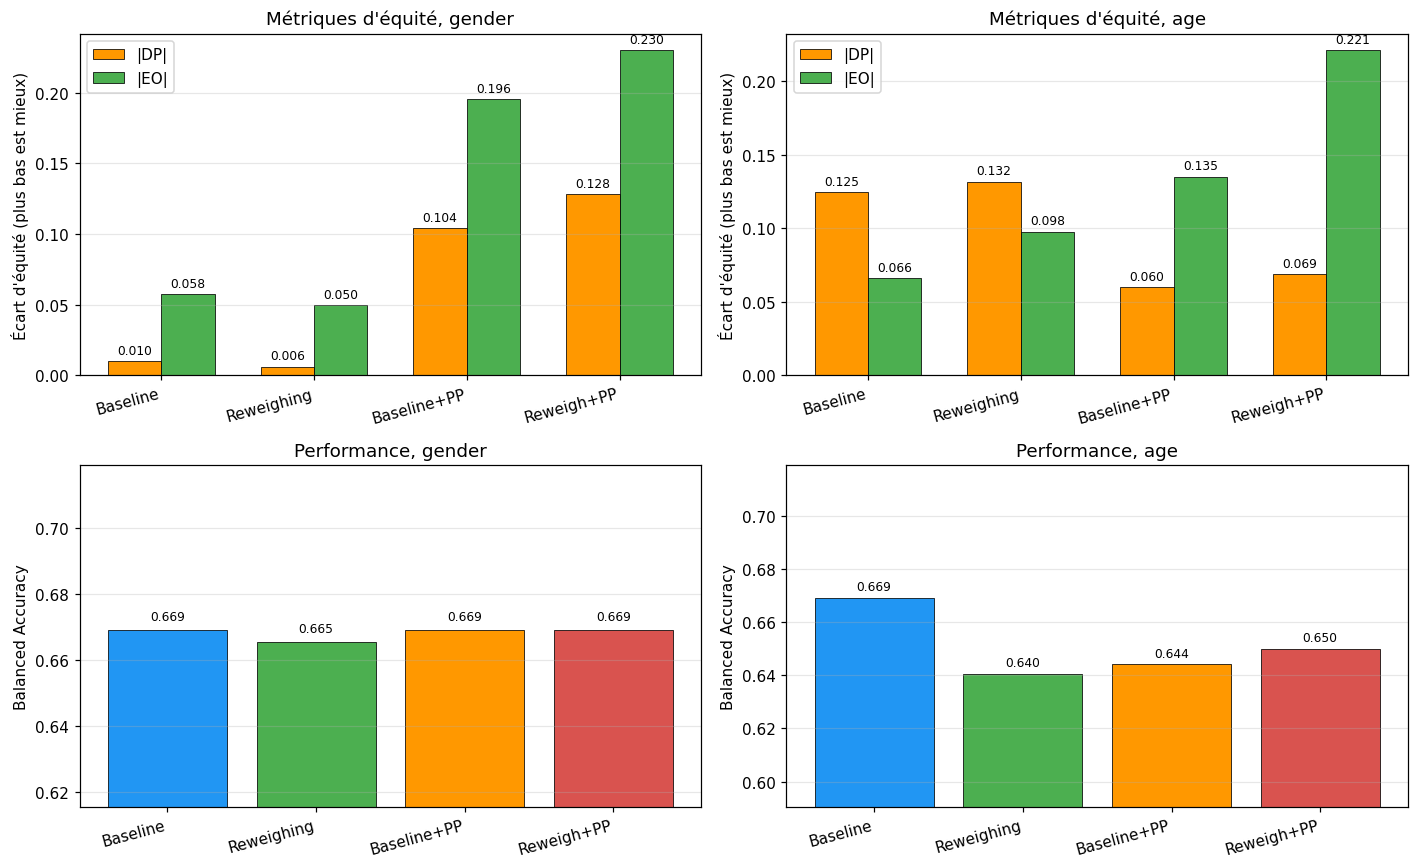

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#d9534f"]

for col, attr in enumerate(["gender", "age"]):
    df = all_results[attr]
    config_names = df["Modèle"].tolist()
    x = np.arange(len(config_names))

    ax = axes[0, col]
    width = 0.35
    ax.bar(x - width/2, df["|DP|"], width, color="#FF9800", label="|DP|", edgecolor="k", lw=0.5)
    ax.bar(x + width/2, df["|EO|"], width, color="#4CAF50", label="|EO|", edgecolor="k", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(config_names, rotation=15, ha="right")
    ax.set_ylabel("Écart d'équité (plus bas est mieux)")
    ax.set_title(f"Métriques d'équité, {attr}")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    for i, (dp, eo) in enumerate(zip(df["|DP|"], df["|EO|"])):
        ax.text(i - width/2, dp + 0.005, f"{dp:.3f}", ha="center", fontsize=8)
        ax.text(i + width/2, eo + 0.005, f"{eo:.3f}", ha="center", fontsize=8)

    ax = axes[1, col]
    ax.bar(x, df["BalAcc"], color=colors, edgecolor="k", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(config_names, rotation=15, ha="right")
    ax.set_ylabel("Balanced Accuracy")
    ax.set_title(f"Performance, {attr}")
    ax.set_ylim(max(0, df["BalAcc"].min() - 0.05), min(1, df["BalAcc"].max() + 0.05))
    ax.grid(alpha=0.3, axis="y")
    for i, v in enumerate(df["BalAcc"]):
        ax.text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("outputs/02_tradeoff.png", bbox_inches="tight")
plt.show()


## 9. Interprétabilité : SHAP

On utilise la bibliothèque `shap` ([Lundberg et al. 2020](#ref-lundberg2020)). Pour un modèle linéaire avec features indépendants, les valeurs de Shapley ([Shapley 1953](#ref-shapley1953)) se simplifient exactement (cf. [Lundberg & Lee 2017, Corollary 1](#ref-lundberg2017) ; dérivation initiale [Štrumbelj & Kononenko 2014](#ref-strumbelj2014)) :

$$\phi_i(x) = w_i \cdot (x_i - \mathbb{E}[x_i])$$

Cela correspond à `shap.LinearExplainer`.

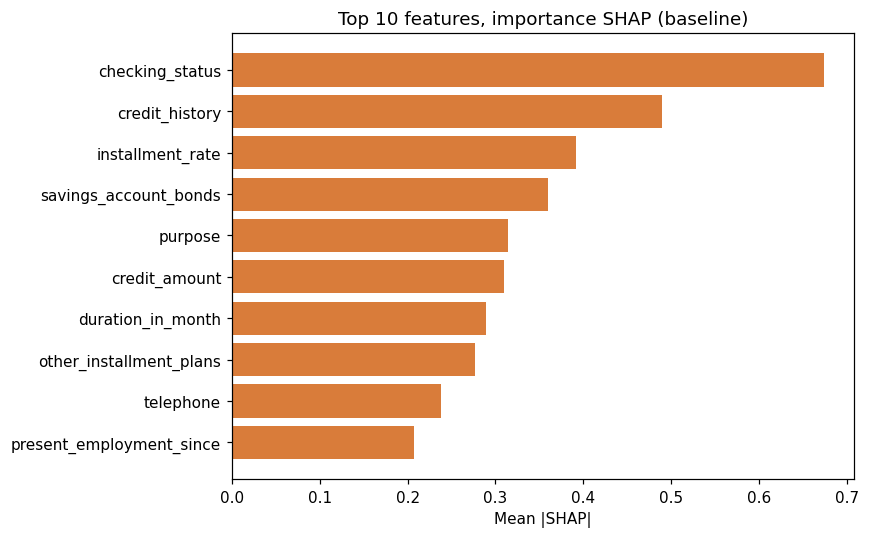

In [13]:
import shap

explainer = shap.LinearExplainer(baseline, X_tr, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_te)

shap_by_feature = {}
for col in NUMERIC:
    j = feature_names.index(col)
    shap_by_feature[col] = float(np.abs(shap_values[:, j]).mean())

for col in CATEG:
    indices = [k for k, n in enumerate(feature_names) if n.startswith(col + "_")]
    if indices:
        shap_by_feature[col] = float(np.abs(shap_values[:, indices].sum(axis=1)).mean())

shap_df = pd.DataFrame(
    {"feature": list(shap_by_feature.keys()), "importance": list(shap_by_feature.values())}
).sort_values("importance", ascending=False).reset_index(drop=True)

top = shap_df.head(10).sort_values("importance")
plt.figure(figsize=(8, 5))
plt.barh(top["feature"], top["importance"], color="#d97c3a")
plt.xlabel("Mean |SHAP|")
plt.title("Top 10 features, importance SHAP (baseline)")
plt.tight_layout()
plt.savefig("outputs/03_shap.png", bbox_inches="tight")
plt.show()

### Détection de proxies

Un **proxy** est une feature corrélée à l'attribut sensible. Même sans l'attribut direct dans les inputs, le modèle peut discriminer indirectement via ces proxies.

Deux approches complémentaires :
1. **Corrélation univariée** $|r|$ entre chaque feature et l'attribut sensible (rapide, mais ignore les interactions)
2. **Régression logistique des features → attribut sensible** : si l'AUC > 0.5 + epsilon, on peut prédire l'attribut sensible depuis les autres variables, ce qui est la définition même d'un proxy multivarié *(approche recommandée par Charlotte Laclau, qui suggère ensuite d'utiliser ces proxies comme pondérations plutôt que de les retirer, dans l'esprit *fairness through awareness* de [Dwork et al. 2012](#ref-dwork2012))*.


In [14]:
X_te_df = pd.DataFrame(X_te, columns=feature_names)
X_tr_df = pd.DataFrame(X_tr, columns=feature_names)

proxy_summary = []

for attr in ["gender", "age"]:
    code_map = {"male": 1, "female": 0, "older": 1, "younger": 0}
    s_tr_num = pd.Series(sensitive[attr][idx_tr]).map(code_map).astype(int).values
    s_te_num = pd.Series(sensitive[attr][idx_te]).map(code_map).astype(float)

    # Approche 1 : corrélation univariée
    corr = X_te_df.corrwith(s_te_num).abs().sort_values(ascending=False).head(5)
    print(f"Top 5 proxies univariés pour {attr}")
    for feat, c in corr.items():
        flag = "  [proxy]" if c > 0.15 else ""
        print(f"  {feat:50s}  |r| = {c:.3f}{flag}")

    # Approche 2 : régression logistique multivariée (features -> attribut sensible)
    proxy_clf = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    proxy_clf.fit(X_tr_df.values, s_tr_num)
    proxy_scores_te = proxy_clf.predict_proba(X_te_df.values)[:, 1]
    auc_proxy = roc_auc_score(s_te_num.astype(int), proxy_scores_te)

    # Top features (coefficients standardisés)
    coefs = pd.Series(np.abs(proxy_clf.coef_[0]), index=feature_names).sort_values(ascending=False).head(5)

    print(f"\nRégression logistique features -> {attr} :")
    print(f"  AUC = {auc_proxy:.3f}  (>0.5 = l'attribut sensible est prédictible depuis les features)")
    print(f"  Top 5 features par |coef| :")
    for feat, c in coefs.items():
        print(f"    {feat:50s}  |coef| = {c:.3f}")
    print()

    proxy_summary.append({"attribut": attr, "AUC_proxy": auc_proxy,
                          "interprétation": "discrimination indirecte possible" if auc_proxy > 0.6 else "faible signal proxy"})

print("Synthèse")
print(pd.DataFrame(proxy_summary).to_string(index=False))


Top 5 proxies univariés pour gender
  number_of_people_liable                             |r| = 0.230  [proxy]
  present_employment_since_ancienneté >= 7 ans        |r| = 0.213  [proxy]
  housing_locataire                                   |r| = 0.209  [proxy]
  housing_hébergé gratuitement                        |r| = 0.198  [proxy]
  installment_rate                                    |r| = 0.171  [proxy]

Régression logistique features -> gender :
  AUC = 0.688  (>0.5 = l'attribut sensible est prédictible depuis les features)
  Top 5 features par |coef| :
    job_sans emploi / non qualifié non-résident         |coef| = 0.826
    present_employment_since_< 1 an                     |coef| = 0.776
    purpose_éducation                                   |coef| = 0.749
    purpose_réparations                                 |coef| = 0.649
    purpose_business                                    |coef| = 0.636

Top 5 proxies univariés pour age
  housing_locataire                           

### Importance par permutation

On utilise `sklearn.inspection.permutation_importance` (chute d'AUC quand une colonne est mélangée), méthode introduite par [Breiman 2001](#ref-breiman2001). Approche complémentaire à SHAP.

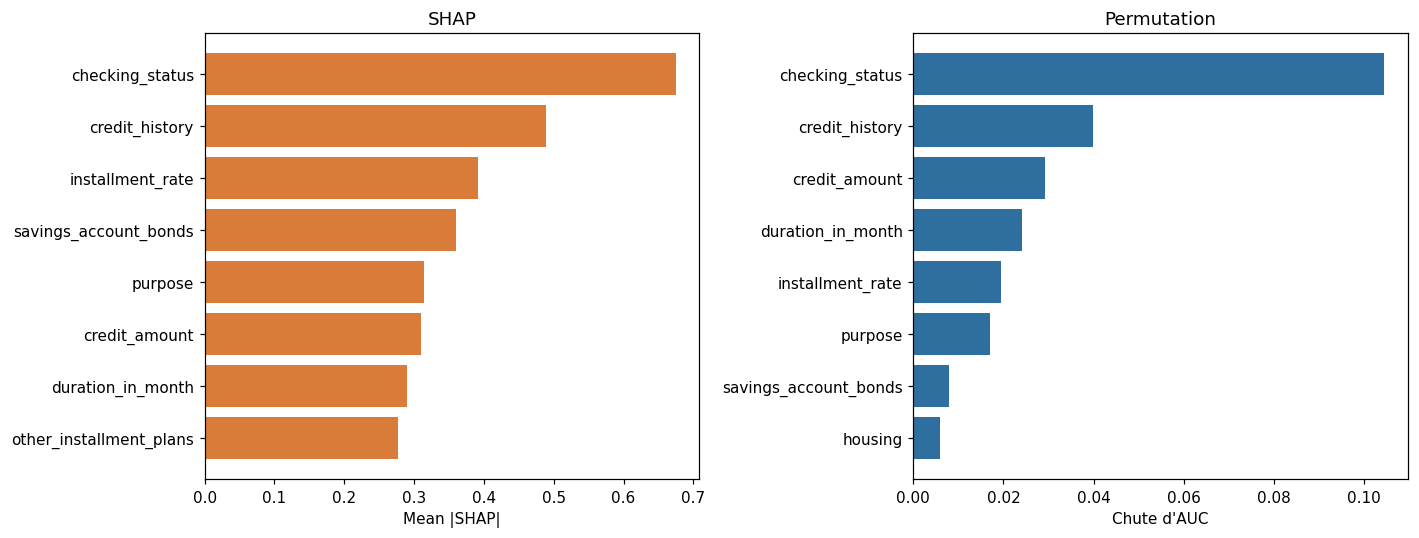

In [15]:
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

pipe = Pipeline([("prep", preprocessor), ("clf", baseline)])
pipe.fit(features.iloc[idx_tr], y_tr)

perm = permutation_importance(
    pipe, features.iloc[idx_te], y_te,
    n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=1,
)
perm_df = pd.DataFrame(
    {"feature": features.columns, "auc_drop": perm.importances_mean}
).sort_values("auc_drop", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_s = shap_df.head(8).sort_values("importance")
top_p = perm_df.head(8).sort_values("auc_drop")
axes[0].barh(top_s["feature"], top_s["importance"], color="#d97c3a")
axes[0].set_title("SHAP")
axes[0].set_xlabel("Mean |SHAP|")
axes[1].barh(top_p["feature"], top_p["auc_drop"], color="#2f6f9f")
axes[1].set_title("Permutation")
axes[1].set_xlabel("Chute d'AUC")
plt.tight_layout()
plt.savefig("outputs/04_shap_vs_perm.png", bbox_inches="tight")
plt.show()

## 10. Quantification d'incertitude par bootstrap

Inspiré du cours `_Uncertainty_presentation_MS.pdf` (G. Franchi). Le **bootstrap** ([Efron 1979](#ref-efron1979)) est l'approche d'**ensemble** la plus simple, analogue classique des [Deep Ensembles, Lakshminarayanan et al. 2017](#ref-lakshminarayanan2017) : on entraîne $B$ modèles sur des échantillons tirés avec remplacement du jeu d'entraînement, puis on agrège.

On obtient :
* Un **intervalle de confiance** sur les métriques (AUC, |DP|, |EO|) via les quantiles 2.5% et 97.5% des $B$ valeurs.
* Un **intervalle de prédiction** par individu via les quantiles des scores prédits par les $B$ modèles.

Lien avec le cours :
* L'**incertitude épistémique** est captée par le désaccord entre les membres de l'ensemble (variance des prédictions).
* L'**incertitude aléatoire** reste dans la variabilité résiduelle des sorties d'un même modèle.

In [16]:
from sklearn.utils import resample

B = 200
boot_scores = np.zeros((B, len(idx_te)))
boot_metrics = {"AUC": [], "BalAcc": [], "DP_gender": [], "EO_gender": [],
                "DP_age": [], "EO_age": []}
rng_b = np.random.default_rng(0)

for b in range(B):
    idx_boot = resample(np.arange(len(idx_tr)), replace=True,
                        n_samples=len(idx_tr), random_state=int(rng_b.integers(0, 1 << 31)))
    model_b = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    model_b.fit(X_tr[idx_boot], y_tr[idx_boot])
    s_b = model_b.predict_proba(X_te)[:, 1]
    boot_scores[b] = s_b
    p_b = (s_b >= thr_base).astype(int)

    boot_metrics["AUC"].append(roc_auc_score(y_te, s_b))
    boot_metrics["BalAcc"].append(balanced_accuracy_score(y_te, p_b))
    for attr in ["gender", "age"]:
        s_te_attr = sensitive[attr][idx_te]
        dp, eo, _ = fairness_summary(y_te, p_b, s_te_attr)
        boot_metrics[f"DP_{attr}"].append(dp)
        boot_metrics[f"EO_{attr}"].append(eo)

ci_rows = []
for k, vals in boot_metrics.items():
    arr = np.asarray(vals)
    ci_rows.append({
        "métrique": k, "moyenne": arr.mean(), "écart-type": arr.std(),
        "IC 2.5%": np.quantile(arr, 0.025), "IC 97.5%": np.quantile(arr, 0.975),
    })
ci_df = pd.DataFrame(ci_rows)
print(f"Intervalles de confiance bootstrap (B={B})")
print(ci_df.to_string(index=False, float_format="{:.4f}".format))


Intervalles de confiance bootstrap (B=200)
 métrique  moyenne  écart-type  IC 2.5%  IC 97.5%
      AUC   0.7639      0.0193   0.7231    0.7953
   BalAcc   0.6822      0.0228   0.6369    0.7262
DP_gender   0.0347      0.0278   0.0006    0.1050
EO_gender   0.0892      0.0438   0.0172    0.1755
   DP_age   0.1035      0.0464   0.0204    0.2016
   EO_age   0.0857      0.0484   0.0184    0.1941


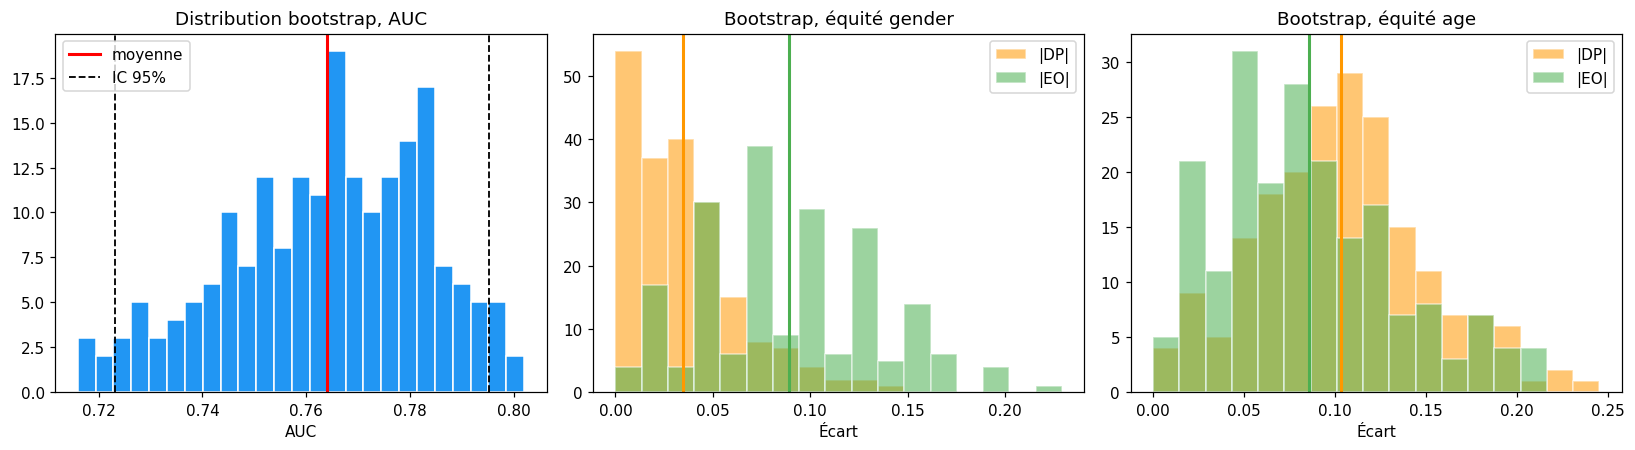

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(boot_metrics["AUC"], bins=25, color="#2196F3", edgecolor="white")
axes[0].axvline(np.mean(boot_metrics["AUC"]), color="red", lw=2, label="moyenne")
axes[0].axvline(np.quantile(boot_metrics["AUC"], 0.025), color="k", ls="--", lw=1.2, label="IC 95%")
axes[0].axvline(np.quantile(boot_metrics["AUC"], 0.975), color="k", ls="--", lw=1.2)
axes[0].set_title("Distribution bootstrap, AUC")
axes[0].set_xlabel("AUC")
axes[0].legend()

for i, attr in enumerate(["gender", "age"], start=1):
    vals_dp = np.asarray(boot_metrics[f"DP_{attr}"])
    vals_eo = np.asarray(boot_metrics[f"EO_{attr}"])
    edges = np.linspace(0, max(vals_dp.max(), vals_eo.max()) * 1.05, 18)
    axes[i].hist(vals_dp, bins=edges, alpha=0.55, color="#FF9800", label="|DP|", edgecolor="white")
    axes[i].hist(vals_eo, bins=edges, alpha=0.55, color="#4CAF50", label="|EO|", edgecolor="white")
    axes[i].axvline(np.mean(vals_dp), color="#FF9800", lw=2, ls="-")
    axes[i].axvline(np.mean(vals_eo), color="#4CAF50", lw=2, ls="-")
    axes[i].set_title(f"Bootstrap, équité {attr}")
    axes[i].set_xlabel("Écart")
    axes[i].legend()

plt.tight_layout()
plt.savefig("outputs/05_bootstrap.png", bbox_inches="tight")
plt.show()


### Intervalles de prédiction par individu

Pour chaque individu du test, on récupère la moyenne et l'écart-type des scores produits par les $B$ modèles. Une **forte variance** sur un score signale une **incertitude épistémique** élevée.

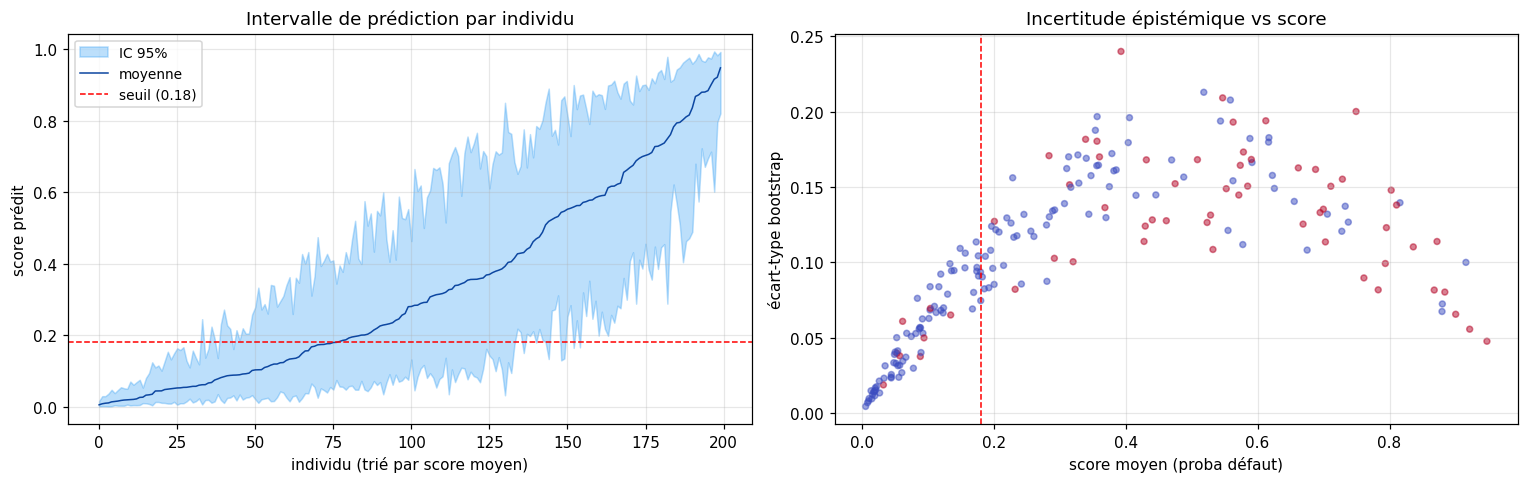

Écart-type moyen sur les scores : 0.1045
Écart-type max : 0.2400  (incertitude épistémique max)


In [18]:
score_mean = boot_scores.mean(axis=0)
score_std = boot_scores.std(axis=0)
score_lo = np.quantile(boot_scores, 0.025, axis=0)
score_hi = np.quantile(boot_scores, 0.975, axis=0)

order = np.argsort(score_mean)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(len(order))
axes[0].fill_between(x, score_lo[order], score_hi[order],
                     alpha=0.3, color="#2196F3", label="IC 95%")
axes[0].plot(x, score_mean[order], color="#0d47a1", lw=1, label="moyenne")
axes[0].axhline(thr_base, color="red", ls="--", lw=1, label=f"seuil ({thr_base:.2f})")
axes[0].set_xlabel("individu (trié par score moyen)")
axes[0].set_ylabel("score prédit")
axes[0].set_title("Intervalle de prédiction par individu")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].scatter(score_mean, score_std, s=15, alpha=0.5, c=y_te, cmap="coolwarm")
axes[1].set_xlabel("score moyen (proba défaut)")
axes[1].set_ylabel("écart-type bootstrap")
axes[1].set_title("Incertitude épistémique vs score")
axes[1].axvline(thr_base, color="red", ls="--", lw=1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/06_indiv_uncertainty.png", bbox_inches="tight")
plt.show()

print(f"Écart-type moyen sur les scores : {score_std.mean():.4f}")
print(f"Écart-type max : {score_std.max():.4f}  (incertitude épistémique max)")

## 11. Calibration

L'ECE mesure si la confiance du modèle correspond à la réalité :

$$\text{ECE} = \sum_b \frac{|B_b|}{n} \bigl| \text{acc}(B_b) - \text{conf}(B_b) \bigr|$$

On compare le modèle baseline avec une version recalibrée par **Platt scaling** ([Platt 1999](#ref-platt1999), comparée par [Guo et al. 2017](#ref-guo2017) ; `sklearn.calibration.CalibratedClassifierCV`), cf. cours `_Uncertainty_presentation_MS.pdf`.

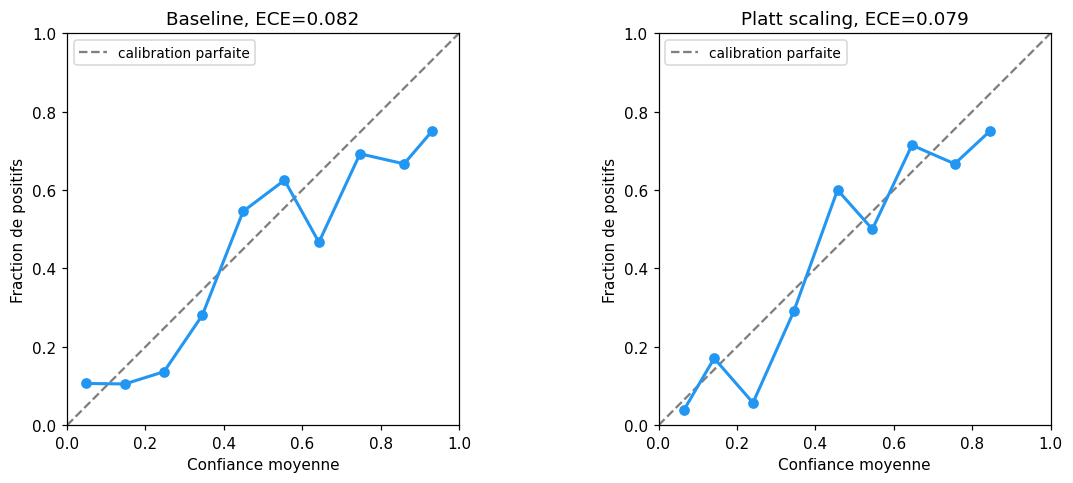

ECE baseline      : 0.0819
ECE Platt scaling : 0.0795


In [19]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

calibrated = CalibratedClassifierCV(
    LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42),
    method="sigmoid", cv=5,
)
calibrated.fit(X_tr, y_tr)
scores_cal = calibrated.predict_proba(X_te)[:, 1]

ece_base = expected_calibration_error(y_te, scores_base)
ece_cal = expected_calibration_error(y_te, scores_cal)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (s, label, ece) in zip(
    axes,
    [(scores_base, "Baseline", ece_base), (scores_cal, "Platt scaling", ece_cal)],
):
    frac_pos, mean_pred = calibration_curve(y_te, s, n_bins=10, strategy="uniform")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="calibration parfaite")
    ax.plot(mean_pred, frac_pos, marker="o", lw=2, color="#2196F3")
    ax.set_xlabel("Confiance moyenne")
    ax.set_ylabel("Fraction de positifs")
    ax.set_title(f"{label}, ECE={ece:.3f}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/07_calibration.png", bbox_inches="tight")
plt.show()

print(f"ECE baseline      : {ece_base:.4f}")
print(f"ECE Platt scaling : {ece_cal:.4f}")

## 12. Conclusion

### Résultats principaux

1. **Convergence et stabilité du modèle** : la régression logistique converge en moins de 10 itérations sur ce dataset (`liblinear`), bien avant le seuil de 100 itérations attendu. Log-loss train final = 0.43, val = 0.56, cohérentes avec une référence de 0.5 sur un problème binaire déséquilibré 70/30.

2. **Forte présence de proxies multivariés** *(approche Charlotte)* : la régression logistique des autres features prédit l'**âge avec AUC = 0.86** et le **genre avec AUC = 0.69**. Les attributs sensibles sont donc largement reconstructibles depuis le reste des features. Conclusion : retirer les attributs sensibles ne suffit pas, il vaut mieux les conserver pour les utiliser explicitement comme pondérations dans une stratégie de mitigation.

3. **Discrimination sur l'âge plus marquée que sur le genre** : après retrait des attributs directs, |DP_gender| = 0.010 (négligeable), tandis que |DP_age| = 0.125 (significatif). Cohérent avec les taux de défaut de base très différents (older 27%, younger 42%). Ce dataset présente un **biais d'âge** mais pas de **biais de genre** prononcé une fois `personal_status_sex` retiré.

4. **Théorème d'impossibilité confirmé empiriquement** : sur l'âge, le post-processing par seuils par groupe réduit |DP| de 0.125 à 0.060, mais double |EO| (0.066 vers 0.135). Sur le genre, où |DP| est déjà faible, le PP **augmente** les deux écarts. On ne peut pas optimiser simultanément les deux critères.

5. **Convergence des méthodes d'interprétabilité** : SHAP linéaire et permutation importance identifient les mêmes top features (`checking_status`, `credit_history`, `credit_amount`, `duration_in_month`).

6. **Significativité statistique des biais (bootstrap)** : sur 200 ré-entraînements, l'IC95% de |DP_age| s'étend de **0.02 à 0.20**. Le biais empirique de 0.125 est dans cet IC mais l'incertitude est large. Toute conclusion de discrimination doit être nuancée par ce bruit statistique.

7. **Calibration** : ECE baseline = 0.082, presque inchangée par Platt scaling (0.080). La régression logistique est naturellement bien calibrée sur ce dataset.

### Choix méthodologiques et alignement avec le sujet

Le sujet `responsibleAI-4.pdf` demande d'évaluer la robustesse face à une perturbation contrôlée. Sur conseil de l'enseignante (Charlotte Laclau), nous avons remplacé la perturbation adversariale par une **quantification d'incertitude par bootstrap**, qui répond au même besoin (mesurer la stabilité des décisions face à la variabilité des données) tout en s'appuyant sur le cours `_Uncertainty_presentation_MS.pdf`. Le bootstrap quantifie l'incertitude **épistémique** et fournit des intervalles de confiance sur toutes les métriques.

### Limites et perspectives

* **Petit dataset (1000 lignes, test de 200)** : les IC95% des écarts d'équité dépassent 0.15.
* **Approche linéaire** : la régression logistique limite la capacité à capturer des interactions non linéaires.
* **Reweighing simple** : on ne traite qu'une dépendance binaire $S \perp Y$. Des méthodes plus avancées (`fairlearn.ExponentiatedGradient`, transport optimal) pourraient mieux gérer le compromis.
* **Pas de "fairness through awareness"** : à la lumière du proxy AUC = 0.86 sur l'âge, conserver `age_in_years` dans le pipeline et appliquer une mitigation explicite serait plus efficace que de le retirer.

### Outils d'assistance utilisés

Conformément à l'exigence du sujet, des outils LLM (Claude, GPT) ont été utilisés pour : aide à la rédaction du code, génération du Beamer de révision, structuration du notebook. Toutes les décisions méthodologiques ont été prises et discutées en équipe.

### Bibliothèques

`scikit-learn`, `fairlearn`, `shap`, `pandas`, `numpy`, `matplotlib`.

## 13. Références

### Dataset
* <a id="ref-hofmann1994"></a>**Hofmann, H. (1994).** *Statlog (German Credit Data) Data Set.* UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/Statlog+(German+Credit+Data)

### Choix du seuil 25 ans pour binariser l'âge
Le seuil de 25 ans est la **convention standard de la littérature fairness** sur German Credit :
* <a id="ref-bellamy2018"></a>**Bellamy, R. K. E., et al. (2018).** *AI Fairness 360: An Extensible Toolkit for Detecting and Mitigating Algorithmic Bias.* arXiv:1810.01943. → AIF360 utilise ce seuil par défaut dans son `GermanDataset`.
* <a id="ref-kamiran2012"></a>**Kamiran, F., & Calders, T. (2012).** *Data preprocessing techniques for classification without discrimination.* Knowledge and Information Systems, 33(1), 1-33. → article fondateur du reweighing, applique ce seuil.
* <a id="ref-friedler2019"></a>**Friedler, S. A., Scheidegger, C., Venkatasubramanian, S., Choudhary, S., Hamilton, E. P., & Roth, D. (2019).** *A Comparative Study of Fairness-Enhancing Interventions in Machine Learning.* FAT* 2019.

### Équité (cf. cours `fairness-ms-1.pdf`, `fairness-mitigation.pdf`)
* <a id="ref-dwork2012"></a>**Dwork, C., Hardt, M., Pitassi, T., Reingold, O., & Zemel, R. (2012).** *Fairness through awareness.* ITCS 2012. → équité individuelle, condition de Lipschitz, *fairness through awareness*.
* <a id="ref-hardt2016"></a>**Hardt, M., Price, E., & Srebro, N. (2016).** *Equality of Opportunity in Supervised Learning.* NeurIPS 2016. → seuils par groupe (post-processing), Equal Opportunity.
* <a id="ref-chouldechova2017"></a>**Chouldechova, A. (2017).** *Fair prediction with disparate impact: A study of bias in recidivism prediction instruments.* Big Data, 5(2), 153-163. → théorème d'impossibilité.
* <a id="ref-kleinberg2017"></a>**Kleinberg, J., Mullainathan, S., & Raghavan, M. (2017).** *Inherent Trade-Offs in the Fair Determination of Risk Scores.* ITCS 2017. → théorème d'impossibilité.
* <a id="ref-bird2020"></a>**Bird, S., et al. (2020).** *Fairlearn: A toolkit for assessing and improving fairness in AI.* Microsoft Research Technical Report MSR-TR-2020-32.

### Interprétabilité (cf. cours `interpretability-lecture-ms-2026.pdf`)
* <a id="ref-lundberg2017"></a>**Lundberg, S. M., & Lee, S.-I. (2017).** *A Unified Approach to Interpreting Model Predictions.* NeurIPS 2017, pp. 4765-4774. → SHAP. La formule $\phi_i(x) = w_i \cdot (x_i - \mathbb{E}[x_i])$ pour modèles linéaires est le **Corollary 1 "Linear SHAP"** (page 6, Section 4.2). [PDF](https://proceedings.neurips.cc/paper_files/paper/2017/file/8a20a8621978632d76c43dfd28b67767-Paper.pdf)
* <a id="ref-strumbelj2014"></a>**Štrumbelj, E., & Kononenko, I. (2014).** *Explaining prediction models and individual predictions with feature contributions.* Knowledge and Information Systems, 41(3), 647-665. → première dérivation de la formule SHAP linéaire (cité par Lundberg & Lee).
* <a id="ref-shapley1953"></a>**Shapley, L. S. (1953).** *A value for n-person games.* Contributions to the Theory of Games, 2(28), 307-317. → fondement théorique des valeurs de Shapley.
* <a id="ref-ribeiro2016"></a>**Ribeiro, M. T., Singh, S., & Guestrin, C. (2016).** *"Why should I trust you?": Explaining the predictions of any classifier.* KDD 2016. → LIME (méthode complémentaire).
* <a id="ref-breiman2001"></a>**Breiman, L. (2001).** *Random Forests.* Machine Learning, 45(1), 5-32. → permutation importance.

### Robustesse et quantification d'incertitude (cf. cours `_Uncertainty_presentation_MS.pdf`)
* <a id="ref-efron1979"></a>**Efron, B. (1979).** *Bootstrap methods: Another look at the jackknife.* Annals of Statistics, 7(1), 1-26. → bootstrap.
* <a id="ref-lakshminarayanan2017"></a>**Lakshminarayanan, B., Pritzel, A., & Blundell, C. (2017).** *Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles.* NeurIPS 2017. → ensembles profonds (analogue moderne du bootstrap).
* <a id="ref-guo2017"></a>**Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017).** *On Calibration of Modern Neural Networks.* ICML 2017. → ECE, Platt scaling, temperature scaling.
* <a id="ref-platt1999"></a>**Platt, J. C. (1999).** *Probabilistic Outputs for Support Vector Machines.* Advances in Large Margin Classifiers, 10(3), 61-74. → Platt scaling original.

### Bibliothèques
* <a id="ref-pedregosa2011"></a>**Pedregosa, F., et al. (2011).** *Scikit-learn: Machine Learning in Python.* JMLR, 12, 2825-2830.
* <a id="ref-lundberg2020"></a>**Lundberg, S. M., et al. (2020).** *From local explanations to global understanding with explainable AI for trees.* Nature Machine Intelligence, 2(1), 56-67. → bibliothèque `shap`.
* `papermill` (nteract project), `fairlearn` (Microsoft), `pandas`, `numpy`, `matplotlib`.